<a href="https://colab.research.google.com/github/Ven0mite/HomeworkFWE_Nelan_Remy/blob/main/Nelan_Remy_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Remy Nelan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
climate_data = pd.DataFrame({
    'month': range(1, 13),
    'month_name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'temp_2023': [-6.2, -4.1, 1.8, 9.5, 15.2, 20.8, 23.5, 22.1, 17.3, 10.2, 3.1, -3.5],
    'temp_2024': [-5.1, -2.8, 3.2, 10.8, 16.5, 22.1, 25.2, 23.8, 18.5, 11.5, 4.2, -2.1],
    'precip_2023': [32, 28, 45, 72, 95, 102, 88, 76, 68, 55, 42, 38],
    'precip_2024': [28, 35, 52, 68, 88, 115, 95, 82, 72, 48, 38, 42]
})

climate_data

,month,month_name,temp_2023,temp_2024,precip_2023,precip_2024
0,1,Jan,-6.2,-5.1,32,28
1,2,Feb,-4.1,-2.8,28,35
2,3,Mar,1.8,3.2,45,52
3,4,Apr,9.5,10.8,72,68
4,5,May,15.2,16.5,95,88
5,6,Jun,20.8,22.1,102,115
6,7,Jul,23.5,25.2,88,95
7,8,Aug,22.1,23.8,76,82
8,9,Sep,17.3,18.5,68,72
9,10,Oct,10.2,11.5,55,48


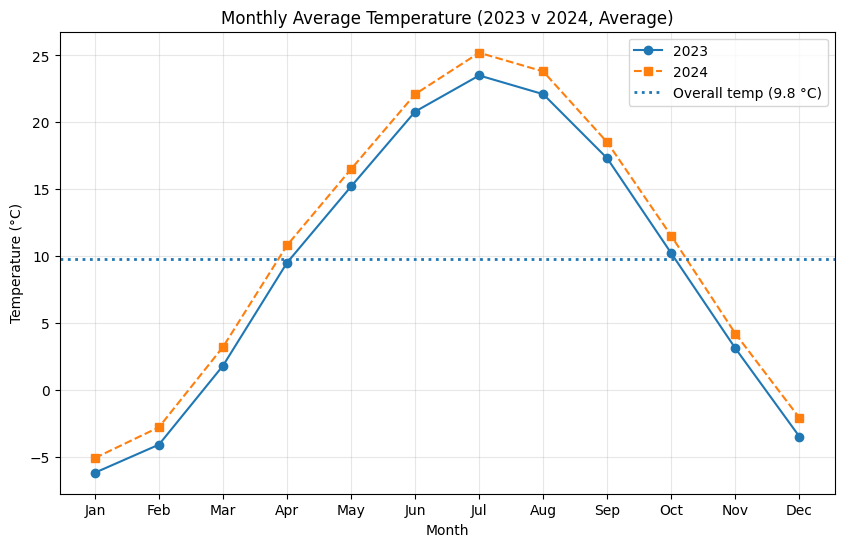

In [8]:
overall_temp = np.mean(
    np.concatenate([climate_data['temp_2023'],
                    climate_data['temp_2024']])
)

overall_temp

# Part 1.A: Create a line plot

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(climate_data['month'], climate_data['temp_2023'], 'o-', label='2023')
ax.plot(climate_data['month'],climate_data['temp_2024'], 's--', label='2024')
ax.axhline(overall_temp, linestyle=':', linewidth=2, label=f'Overall temp ({overall_temp:.1f} °C)')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Monthly Average Temperature (2023 v 2024, Average)')
ax.set_xticks(climate_data['month'])
ax.set_xticklabels(climate_data['month_name'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

(0.0, 132.25)

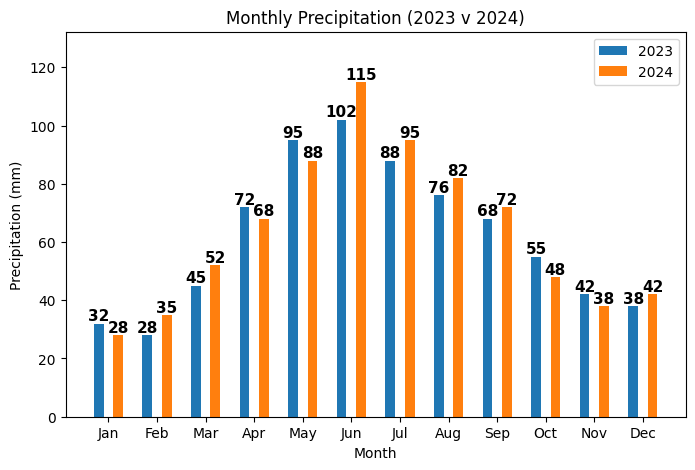

In [12]:
# Part 1.B: Create a grouped bar chart

fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(climate_data['month_name']))
width = 0.2

bars1 = ax.bar(x - width, climate_data['precip_2023'], width, label='2023')
bars2 = ax.bar(x + width, climate_data['precip_2024'], width, label='2024')
for bar in bars1:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2,
          height + 1, f'{int(height)}', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2,
          height + 1, f'{int(height)}', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Monthly Precipitation (2023 v 2024)')
ax.set_xticks(x)
ax.set_xticklabels(climate_data['month_name'])
ax.legend()
ax.set_ylim(0, max(climate_data['precip_2023'].max(),
                   climate_data['precip_2024'].max()) * 1.15)

In [13]:
# Bird survey data
np.random.seed(458)
n_per_habitat = 50

bird_data = pd.DataFrame({
    'habitat': np.repeat(['Forest', 'Wetland', 'Grassland'], n_per_habitat),
    'wing_length_mm': np.concatenate([
        np.random.normal(85, 8, n_per_habitat),   # Forest
        np.random.normal(92, 10, n_per_habitat),  # Wetland
        np.random.normal(78, 7, n_per_habitat)    # Grassland
    ]),
    'body_mass_g': np.concatenate([
        np.random.normal(28, 4, n_per_habitat),   # Forest
        np.random.normal(35, 6, n_per_habitat),   # Wetland
        np.random.normal(24, 3, n_per_habitat)    # Grassland
    ])
})

bird_data.head()

,habitat,wing_length_mm,body_mass_g
0,Forest,81.927461,23.185356
1,Forest,80.536893,22.835132
2,Forest,80.362027,28.452494
3,Forest,97.862415,27.982051
4,Forest,98.177658,32.304888


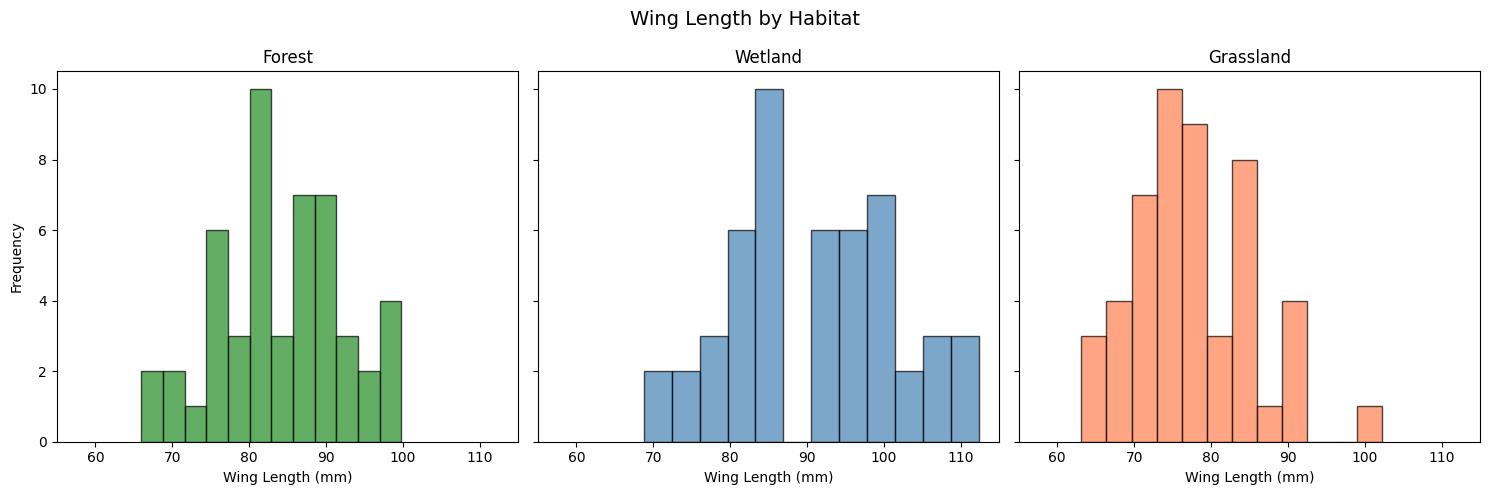

In [19]:
# 2.A: Create a single figure with 1 row and 3 columns

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

habitats = ['Forest', 'Wetland', 'Grassland']
colors = ['forestgreen', 'steelblue', 'coral']

for ax, habitat, color in zip(axes, habitats, colors):
  data = bird_data[bird_data['habitat'] == habitat]['wing_length_mm']
  ax.hist(data,  bins=12, color=color, edgecolor='black', alpha=0.7)
  ax.set_title(habitat)
  ax.set_xlabel('Wing Length (mm)')
  ax.set_xlim(55, 115)

axes[0].set_ylabel('Frequency')

plt.suptitle('Wing Length by Habitat', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1341/2014167870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


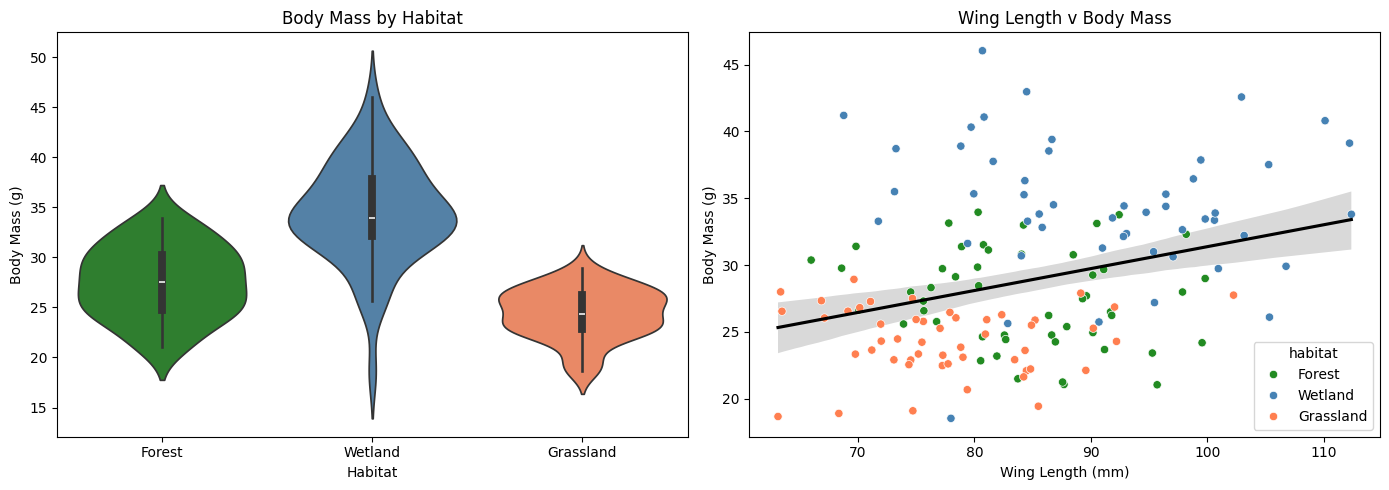

In [20]:
# Part 2.B: Create a single figure with 1 row and 2 columns

fig, axes = plt.subplots(1, 2, figsize = (14,5))

sns.violinplot(
    data=bird_data, x='habitat', y='body_mass_g', palette=['forestgreen', 'steelblue', 'coral'], ax=axes[0]
)
axes[0].set_title('Body Mass by Habitat')
axes[0].set_xlabel('Habitat')
axes[0].set_ylabel('Body Mass (g)')

sns.regplot(
    data=bird_data, x='wing_length_mm', y='body_mass_g', scatter=False, ax=axes[1], color='black'
)

sns.scatterplot(
    data=bird_data, x='wing_length_mm', y='body_mass_g', hue='habitat', palette=['forestgreen', 'steelblue', 'coral'], ax=axes[1]
)

axes[1].set_title('Wing Length v Body Mass')
axes[1].set_xlabel('Wing Length (mm)')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
fig.savefig('bird_analysis.png', dpi=300)
plt.show()

In [21]:
# Lake monitoring data (May - September 2024)
np.random.seed(123)

dates = pd.date_range('2024-05-01', '2024-09-30', freq='D')
n_days = len(dates)

# Temperature increases through summer then decreases
day_of_period = np.arange(n_days)
temp_pattern = 18 + 8 * np.sin(np.pi * day_of_period / n_days)

lake_data = pd.DataFrame({
    'date': dates,
    'month': dates.month,
    'temperature_c': temp_pattern + np.random.normal(0, 1.5, n_days),
    'dissolved_oxygen_mg_l': 12 - 0.3 * temp_pattern + np.random.normal(0, 1, n_days),
    'chlorophyll_ug_l': 5 + 0.4 * temp_pattern + np.random.exponential(2, n_days),
    'secchi_depth_m': np.random.normal(3.5, 0.8, n_days).clip(min=0.5)
})

# Ensure DO stays positive
lake_data['dissolved_oxygen_mg_l'] = lake_data['dissolved_oxygen_mg_l'].clip(lower=2)

lake_data.head()

,date,month,temperature_c,dissolved_oxygen_mg_l,chlorophyll_ug_l,secchi_depth_m
0,2024-05-01,5,16.371554,4.723131,15.226135,3.531924
1,2024-05-02,5,19.660273,5.531069,12.807950,3.632816
2,2024-05-03,5,18.752908,6.669410,13.140048,3.637571
3,2024-05-04,5,16.233045,7.006110,18.542097,3.123518
4,2024-05-05,5,17.788426,5.872427,14.607339,2.720625


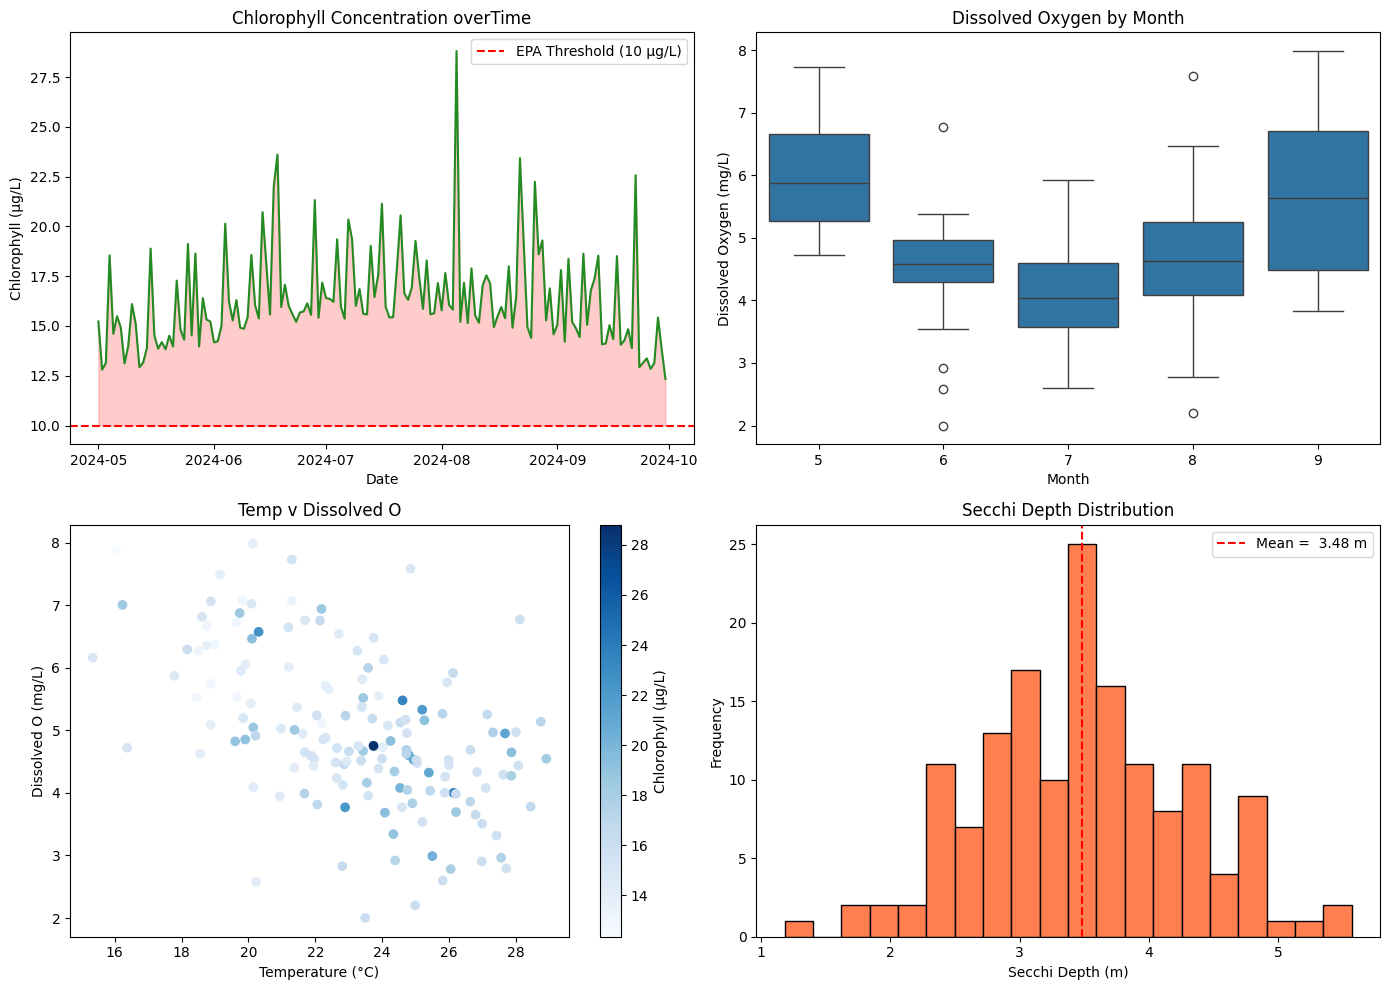

In [30]:
# Part 3: Create a single figure with 4 panels (2 rows x 2 columns)

fig, axes = plt.subplots(2,2, figsize=(14, 10))

ax1 = axes[0,0]
ax1.plot(lake_data['date'], lake_data['chlorophyll_ug_l'], color='forestgreen')
ax1.axhline(10, color='red', linestyle='--', label='EPA Threshold (10 µg/L)')
ax1.fill_between(lake_data['date'], lake_data['chlorophyll_ug_l'], 10, color='red', alpha=0.2)
ax1.set_title('Chlorophyll Concentration overTime')
ax1.set_xlabel('Date')
ax1.set_ylabel('Chlorophyll (µg/L)')
ax1.legend()

ax2 = axes[0, 1]
data1 = lake_data[(lake_data['month'] >= 5) & (lake_data['month'] <= 9)]
sns.boxplot(data=data1, x='month', y='dissolved_oxygen_mg_l', ax=ax2)
ax2.set_title('Dissolved Oxygen by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Dissolved Oxygen (mg/L)')

ax3 = axes[1, 0]
scatter = ax3.scatter(lake_data['temperature_c'], lake_data['dissolved_oxygen_mg_l'], c=lake_data['chlorophyll_ug_l'], cmap='Blues')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Chlorophyll (µg/L)')
ax3.set_title('Temp v Dissolved O')
ax3.set_xlabel('Temperature (°C)')
ax3.set_ylabel('Dissolved O (mg/L)')

ax4 = axes[1, 1]
ax4.hist(lake_data['secchi_depth_m'], bins=20, color='coral', edgecolor='black')

secchi_mean = lake_data['secchi_depth_m'].mean()
ax4.axvline(secchi_mean, color='red', linestyle='--', label=f'Mean = {secchi_mean: .2f} m')
ax4.set_title('Secchi Depth Distribution')
ax4.set_xlabel('Secchi Depth (m)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
fig.savefig('water_quality_dashboard.png', dpi=300)
plt.show()